In [24]:
# Import Libraries
import ast
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

# Loading the dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleaning
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [25]:
df_DA_DE = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'Germany')].copy()

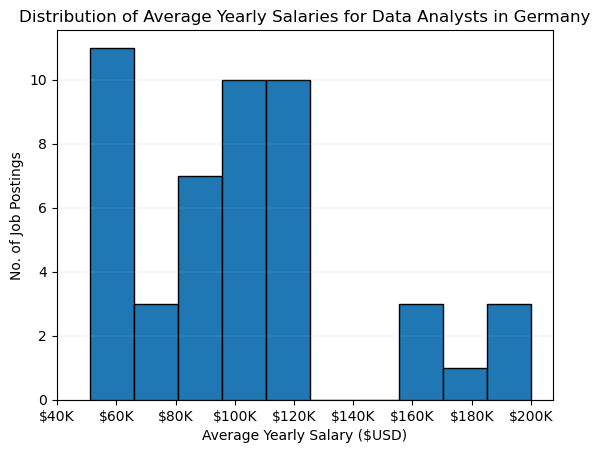

In [30]:
df_DA_DE['salary_year_avg'].plot(kind='hist', bins=10, edgecolor='black')

ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

plt.title('Distribution of Average Yearly Salaries for Data Analysts in Germany')
plt.xlabel('Average Yearly Salary ($USD)')
plt.xlim(40000)
plt.ylabel('No. of Job Postings')
plt.grid(axis='y', alpha=0.75, linewidth=0.2)
plt.show()